In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
from datetime import datetime
pd.set_option('display.max_rows', None)

In [26]:
#print(tf.config.list_physical_devices('GPU'))

componentsA = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetA_components.csv')
eventsA = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetA_events.csv')
componentsB = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetB_components.csv')
eventsB = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetB_events.csv')
componentsC = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetC_components.csv')
eventsC = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetC_events.csv')
componentsD = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetD_components.csv')
eventsD = pd.read_csv('/mnt/c/Users/Admin/OneDrive - Budapesti Műszaki és Gazdaságtudományi Egyetem/School/BME/S6/Onlab/data/SCLDDoS2024_SetD_events.csv')


In [27]:
componentsA = pd.read_csv('data/SCLDDoS2024_SetA_components.csv')
eventsA = pd.read_csv('data/SCLDDoS2024_SetA_events.csv')
componentsB = pd.read_csv('data/SCLDDoS2024_SetB_components.csv')
eventsB = pd.read_csv('data/SCLDDoS2024_SetB_events.csv')
componentsC = pd.read_csv('data/SCLDDoS2024_SetC_components.csv')
eventsC = pd.read_csv('data/SCLDDoS2024_SetC_events.csv')
componentsD = pd.read_csv('data/SCLDDoS2024_SetD_components.csv')
eventsD = pd.read_csv('data/SCLDDoS2024_SetD_events.csv')

In [28]:
eventsA.columns

Index(['Attack ID', 'Card', 'Victim IP', 'Port number', 'Attack code',
       'Detect count', 'Significant flag', 'Packet speed', 'Data speed',
       'Avg packet len', 'Avg source IP count', 'Start time', 'End time',
       'Whitelist flag', 'Type'],
      dtype='object')

In [29]:
eventsA.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)
eventsB.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)
eventsC.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)
eventsD.drop(columns=[ 'Card', 'Victim IP', 'Port number', 'Attack code','Detect count', 'Significant flag', 'Packet speed', 'Data speed','Avg packet len', 'Whitelist flag'], inplace=True)

In [30]:
A = pd.merge(eventsA, componentsA, on='Attack ID')
B = pd.merge(eventsB, componentsB, on='Attack ID')
C = pd.merge(eventsC, componentsC, on='Attack ID')
D = pd.merge(eventsD, componentsD, on='Attack ID')

In [31]:
train = pd.concat([A, B])
test = C
val = D

In [9]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Transform 'Type' column
train['Type'] = le.fit_transform(train['Type'])
test['Type'] = le.fit_transform(test['Type'])
val['Type'] = le.fit_transform(val['Type'])

In [32]:
train.columns

Index(['Attack ID', 'Avg source IP count', 'Start time', 'End time', 'Type',
       'Detect count', 'Card', 'Victim IP', 'Port number', 'Attack code',
       'Significant flag', 'Packet speed', 'Data speed', 'Avg packet len',
       'Source IP count', 'Time'],
      dtype='object')

In [11]:
"""def count_differences(df, col_x, col_y):
    return (df[col_x] != df[col_y]).sum() / len(df) * 100

columns_to_compare = [
    ('Significant flag_x', 'Significant flag_y'),
    ('Card_x', 'Card_y'),
    ('Victim IP_x', 'Victim IP_y'),
    ('Port number_x', 'Port number_y'),
    ('Attack code_x', 'Attack code_y'),
    ('Detect count_x', 'Detect count_y'),
    ('Packet speed_x', 'Packet speed_y'),
    ('Data speed_x', 'Data speed_y'),
    ('Avg packet len_x', 'Avg packet len_y')
]

for col_x, col_y in columns_to_compare:
    train[f'diff_{col_x}_{col_y}'] = count_differences(train, col_x, col_y)
    test[f'diff_{col_x}_{col_y}'] = count_differences(test, col_x, col_y)
    val[f'diff_{col_x}_{col_y}'] = count_differences(val, col_x, col_y)

train.head()"""

"def count_differences(df, col_x, col_y):\n    return (df[col_x] != df[col_y]).sum() / len(df) * 100\n\ncolumns_to_compare = [\n    ('Significant flag_x', 'Significant flag_y'),\n    ('Card_x', 'Card_y'),\n    ('Victim IP_x', 'Victim IP_y'),\n    ('Port number_x', 'Port number_y'),\n    ('Attack code_x', 'Attack code_y'),\n    ('Detect count_x', 'Detect count_y'),\n    ('Packet speed_x', 'Packet speed_y'),\n    ('Data speed_x', 'Data speed_y'),\n    ('Avg packet len_x', 'Avg packet len_y')\n]\n\nfor col_x, col_y in columns_to_compare:\n    train[f'diff_{col_x}_{col_y}'] = count_differences(train, col_x, col_y)\n    test[f'diff_{col_x}_{col_y}'] = count_differences(test, col_x, col_y)\n    val[f'diff_{col_x}_{col_y}'] = count_differences(val, col_x, col_y)\n\ntrain.head()"

In [12]:
"""train.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)
test.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)
val.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)"""

"train.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)\ntest.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)\nval.drop(columns=['Significant flag_x', 'Whitelist flag', 'Significant flag_y', 'Card_x', 'Card_y', 'Victim IP_x', 'Time', 'Port number_x', 'Avg packet len_x', 'Detect count_x', 'Packet speed_x', 'Data speed_x'], inplace=True)"

In [33]:
num_cols = train.select_dtypes(include=[np.number]).columns
num_cols

Index(['Attack ID', 'Avg source IP count', 'Detect count', 'Port number',
       'Significant flag', 'Packet speed', 'Data speed', 'Avg packet len',
       'Source IP count'],
      dtype='object')

for column in num_cols:
plt.figure(figsize=(10, 6))
sns.boxplot(x=train[column])
plt.title(f'Boxplot for {column}')
plt.show()


In [34]:
train = train[train['End time'] != '0']
test = test[test['End time'] != '0']
val = val[val['End time'] != '0']

In [35]:
dataframes = {'train': train, 'test': test, 'val': val}

In [36]:
cat_cols = ['Attack code']

In [37]:
from sklearn.preprocessing import MultiLabelBinarizer

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    train[cat] = train[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(train[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    train = train.join(encoded_categories)

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    test[cat] = test[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(test[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    test = test.join(encoded_categories)

for cat in cat_cols:
    # 🔹 Step 1: Convert comma-separated strings into lists
    val[cat] = val[cat].apply(lambda x: x.split(','))

    # 🔹 Step 2: Use MultiLabelBinarizer to encode
    mlb = MultiLabelBinarizer()
    encoded_categories = pd.DataFrame(mlb.fit_transform(val[cat]), columns=mlb.classes_)
    encoded_categories = encoded_categories.add_prefix(f'{cat}_')

    # 🔹 Step 3: Merge back with original DataFrame
    val = val.join(encoded_categories)
train.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_22024\1104804905.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val[cat] = val[cat].apply(lambda x: x.split(','))


,Attack ID,Avg source IP count,Start time,End time,Type,Detect count,Card,Victim IP,Port number,Attack code,...,Attack code_NTP,Attack code_RDP,Attack code_RPC,Attack code_SNMP,Attack code_SSDP,Attack code_SYN Attack,Attack code_Sentinel,Attack code_Suspicious traffic,Attack code_TCP Anomaly,Attack code_WSD
0,1,6,2022-08-08T18:09:36,2022-08-08T18:09:37,Normal traffic,1,sga10gq0,IP_0001,4500,[High volume traffic],...,0,0,0,0,0,0,0,0,0,0
1,2,1,2022-08-08T18:37:28,2022-08-08T18:37:28,Normal traffic,1,sga10gq0,IP_0002,4500,[High volume traffic],...,0,0,0,0,0,0,0,0,0,0
2,3,1,2022-08-08T18:41:25,2022-08-08T18:41:26,Normal traffic,1,sga10gq0,IP_0003,1200,[High volume traffic],...,0,0,0,0,0,0,0,0,0,0
3,3,1,2022-08-08T18:41:25,2022-08-08T18:41:26,Normal traffic,2,sga10gq0,IP_0003,1200,[High volume traffic],...,0,0,0,0,0,0,0,0,0,0
4,4,1,2022-08-08T18:47:49,2022-08-08T18:47:50,Normal traffic,1,sga10gq0,IP_0002,4500,[High volume traffic],...,0,0,0,0,0,0,0,0,0,0


In [38]:
import re
train['Victim IP'] = train['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))
test['Victim IP'] = test['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))
val['Victim IP'] = val['Victim IP'].apply(lambda x: int(re.search(r'\d+', x).group()))

In [39]:
from sklearn.preprocessing import MinMaxScaler

columns_to_scale = ['Packet speed', 'Data speed', 'Avg packet len']

scaler = MinMaxScaler()

train[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(train[columns_to_scale])
test[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(test[columns_to_scale])
val[[col + '_normalized' for col in columns_to_scale]] = scaler.fit_transform(val[columns_to_scale])

In [40]:
train.columns

Index(['Attack ID', 'Avg source IP count', 'Start time', 'End time', 'Type',
       'Detect count', 'Card', 'Victim IP', 'Port number', 'Attack code',
       'Significant flag', 'Packet speed', 'Data speed', 'Avg packet len',
       'Source IP count', 'Time', 'Attack code_ ACK Attack',
       'Attack code_ CHARGEN', 'Attack code_ CLDAP', 'Attack code_ CoAP',
       'Attack code_ DNS', 'Attack code_ High volume traffic',
       'Attack code_ ICMP', 'Attack code_ IPv4 fragmentation',
       'Attack code_ Memcached', 'Attack code_ NTP', 'Attack code_ RDP',
       'Attack code_ RPC', 'Attack code_ SNMP', 'Attack code_ SSDP',
       'Attack code_ SYN Attack', 'Attack code_ WSD', 'Attack code_CLDAP',
       'Attack code_CoAP', 'Attack code_DNS', 'Attack code_Generic UDP',
       'Attack code_High volume traffic', 'Attack code_ICMP',
       'Attack code_IPv4 fragmentation', 'Attack code_Memcached',
       'Attack code_NTP', 'Attack code_RDP', 'Attack code_RPC',
       'Attack code_SNMP', 'Att

In [41]:
# Drop columns starting with 'diff_'
train = train[[col for col in train.columns if not col.startswith('diff_')]]
test = test[[col for col in test.columns if not col.startswith('diff_')]]
val = val[[col for col in val.columns if not col.startswith('diff_')]]

In [ ]:
"""train.to_parquet('data/train.parquet', index=False)
test.to_parquet('data/test.parquet', index=False)
val.to_parquet('data/val.parquet', index=False)"""

"train.to_parquet('data/train.parquet', index=False)\ntest.to_parquet('data/test.parquet', index=False)\nval.to_parquet('data/val.parquet', index=False)"

In [ ]:
x_cols = ['Avg source IP count', 'Detect count', 'Victim IP', 'Port number',
       'Significant flag', 'Packet speed', 'Data speed', 'Avg packet len',
       'Source IP count','Packet speed_normalized',
       'Data speed_normalized', 'Avg packet len_normalized']

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

rfc = RandomForestClassifier(random_state=42, verbose=1)

rfc.fit(train[x_cols], train['Type'])

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.6min


RandomForestClassifier(random_state=42, verbose=1)

In [26]:
val['Attack code_ RDP'] = 0
val[ 'Attack code_ RPC'] = 0
val['Attack code_ WSD'] = 0
val['Attack code_Sentinel'] = 0
val['Attack code_WSD'] = 0

In [27]:
# Predict the labels for the test data
val['pred'] = rfc.predict(val[x_cols])

# Evaluate the model
accuracy = accuracy_score(val['Type'], val['pred'])
print("Accuracy:", accuracy)
precision = precision_score(val['Type'], val['pred'], average='macro')
print("Precision:", precision)
recall = recall_score(val['Type'], val['pred'], average='macro')
print("Recall:", recall)
f1 = f1_score(val['Type'], val['pred'], average='macro')
print("F1-Score:", f1)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.4s


Accuracy: 0.8456283946414069
Precision: 0.8811731985437702
Recall: 0.6858179114580066
F1-Score: 0.6601729735513006


In [28]:
feature_importances = pd.Series(rfc.feature_importances_, index=x_cols)
feature_importances = feature_importances.sort_values(ascending=False)

print("Feature Importances:")
print(feature_importances)

Feature Importances:
Detect count                        3.393710e-01
Avg source IP count                 9.788939e-02
Victim IP                           6.385074e-02
Port number                         6.367514e-02
Source IP count                     6.102781e-02
Packet speed                        5.824660e-02
Packet speed_normalized             5.770111e-02
Avg packet len                      5.070761e-02
Avg packet len_normalized           4.888135e-02
Data speed                          4.727896e-02
Data speed_normalized               4.542494e-02
Attack code_High volume traffic     2.117136e-02
Attack code_Suspicious traffic      1.955382e-02
Significant flag                    9.818838e-03
Attack code_ High volume traffic    3.220191e-03
Attack code_Generic UDP             2.679587e-03
Attack code_CLDAP                   1.827821e-03
Attack code_ CLDAP                  1.788643e-03
Attack code_ DNS                    1.235098e-03
Attack code_ SYN Attack             9.798775e-04

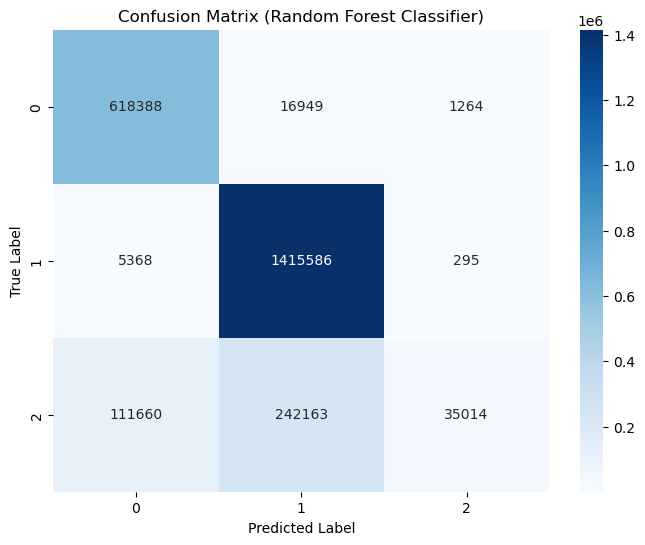

Confusion Matrix (Random Forest Classifier):
 [[ 618388   16949    1264]
 [   5368 1415586     295]
 [ 111660  242163   35014]]


In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


# 1. Generate the confusion matrix
cm = confusion_matrix(val['Type'], val['pred'])

# 2. Visualize the confusion matrix (optional, but highly recommended)
class_labels = np.unique(val['Type']) # Get unique class labels

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Random Forest Classifier)')
plt.show()

# 3. Print the confusion matrix (textual representation)
print("Confusion Matrix (Random Forest Classifier):\n", cm)

In [30]:
from sklearn.metrics import classification_report
import numpy as np

# Generate the classification report
report = classification_report(val['pred'], val['Type'])

# Print the classification report
print("Classification Report (Random Forest Classifier):\n", report)

Classification Report (Random Forest Classifier):
               precision    recall  f1-score   support

           0       0.97      0.84      0.90    735416
           1       1.00      0.85      0.91   1674698
           2       0.09      0.96      0.16     36573

    accuracy                           0.85   2446687
   macro avg       0.69      0.88      0.66   2446687
weighted avg       0.98      0.85      0.90   2446687



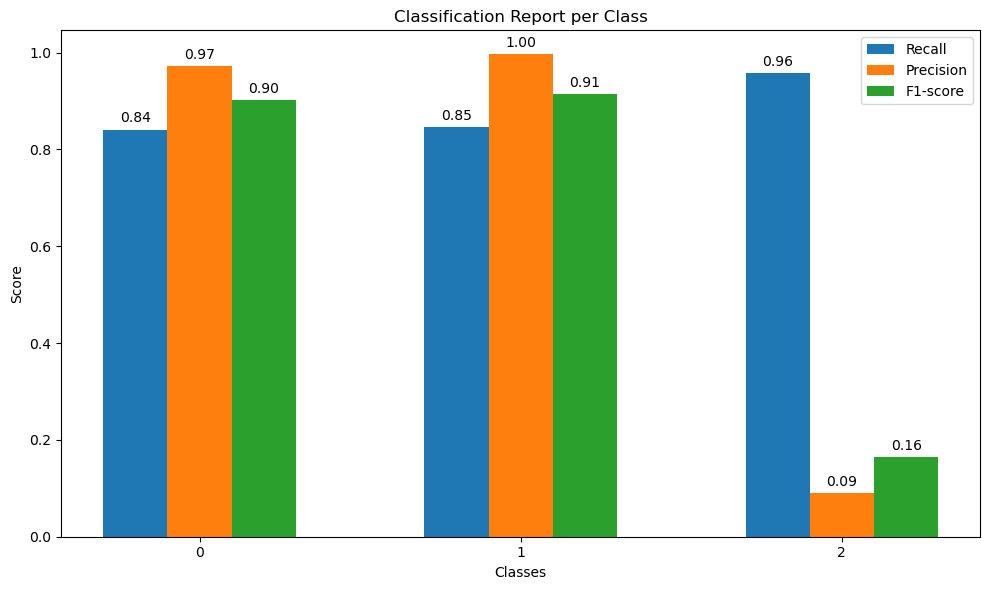

In [31]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Generate the classification report as a dictionary
report = classification_report(val['Type'], val['pred'], output_dict=True)

# 2. Extract the data for plotting
classes = list(report.keys())[:-3]  # Exclude 'accuracy', 'macro avg', 'weighted avg'
precision = [report[cls]['precision'] for cls in classes]
recall = [report[cls]['recall'] for cls in classes]
f1_score = [report[cls]['f1-score'] for cls in classes]

# 3. Set up the plot
x = np.arange(len(classes))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision, width, label='Recall')
rects2 = ax.bar(x, recall, width, label='Precision')
rects3 = ax.bar(x + width, f1_score, width, label='F1-score')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Score')
ax.set_xlabel('Classes')
ax.set_title('Classification Report per Class')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()

ax.bar_label(rects1, fmt='%.2f', padding=3)
ax.bar_label(rects2, fmt='%.2f', padding=3)
ax.bar_label(rects3, fmt='%.2f', padding=3)

fig.tight_layout()
plt.show()